# pMMR: Neighborhood analysis between responders and non-responders for all cell types

In [118]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import time
import sys
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
import seaborn as sns
import math
import os
import re

from scipy.spatial import cKDTree
from scipy.spatial import distance_matrix
from scipy.stats import ttest_ind
from itertools import combinations
import pandas as pd
import statsmodels.stats.multitest as smm

from scipy import stats

import matplotlib.cm as cm
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [119]:
import matplotlib.pyplot as plt
plt.rcdefaults()


I am working with these ROIs in here:

In [120]:
path = "/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/"

all_files = os.listdir(path)
pattern = re.compile(r'(.+)_sigma_binary_res')

# Extract matching sample names
sample_names = []
for file in all_files:
    match = pattern.match(file)
    if match:
        sample_names.append(match.group(1)) 

In [121]:
#create def to create a new table:
all_sample_merged_table= []
for sample_name in sample_names:
    annota_table = pd.read_table(f'/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/{sample_name}_sigma_binary_res/cell_annotation.txt')
    raw_table = pd.read_csv(f'/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/{sample_name}_sigma_binary_res/raw_metadata.csv')
    #print(annota_table['cell_id'].isin(raw_table['Object Id']).all())
    merged_table = pd.merge(
        raw_table,
        annota_table,
        left_on='Object Id',
        right_on='cell_id',
        how='inner'
    )
    merged_table['sample_region']=sample_name
    all_sample_merged_table.append(merged_table)

all_sample_merged_table = pd.concat(all_sample_merged_table, axis=0).reset_index(drop=True)

In [122]:
all_zscore_table= []
for sample_name in sample_names:
    norm_data = pd.read_csv(f'/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/{sample_name}_sigma_binary_res/z_score_normalization.csv')
    norm_data['sample_region']=sample_name
    all_zscore_table.append(norm_data)

all_zscore_table = pd.concat(all_zscore_table, axis=0).reset_index(drop=True)

In [123]:
all_sample_merged_table2 = all_sample_merged_table

In [124]:
all_sample_merged_table2.loc[all_sample_merged_table2['sample_region'] == 'NEST1-06_tumor_inner', 'sample_region'] = 'NEST1-06_tumor_bed'

In [125]:
normalized_df = all_sample_merged_table2.merge(all_zscore_table, on=['cell_id', 'sample_region'], how='left')


In [126]:
#rename cell types
probes_list =pd.read_csv("marker_files/probes_cell_type_table.csv",header=0)
normalized_df = pd.merge(normalized_df, probes_list, on="celll_type")

In [127]:
#select just the sample names, cell type of interest, X_mean and Y_mean and Cell Area
columns_to_Select = ['sample_region','new_cell_type_name','Cell Area (µm²)','xmean', 'ymean']
sub_df = normalized_df[columns_to_Select]

In [128]:
#sub_df

In [129]:
#they have decided to combine cell types.
sub_df["combined_names"]=sub_df["new_cell_type_name"]
sub_df.loc[sub_df['new_cell_type_name'] == 'CD4', 'combined_names'] = 'CD4_T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD3E_CD4 (CD4_Tcell)', 'combined_names'] = 'CD4_T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD4_LAG3_Tcell', 'combined_names'] = 'CD4_T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD8', 'combined_names'] = 'CD8_T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD3E_CD8 (CD8_Tcell)', 'combined_names'] = 'CD8_T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD8_LAG3_Tcell', 'combined_names'] = 'CD8_T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD3E_CD4_CD8 (Tcell)', 'combined_names'] = 'T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'LAG3_Tcell', 'combined_names'] = 'T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'FOXP3', 'combined_names'] = 'T_reg'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD3E_FOXP3 (T_regs)', 'combined_names'] = 'T_reg'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD3E_CD8_FOXP3 (CD8_Tregs)', 'combined_names'] = 'CD8_Treg'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD3E_CD4_FOXP3 (CD4_Tregs)', 'combined_names'] = 'CD4_Treg'
sub_df.loc[sub_df['new_cell_type_name'] == 'Macrophages', 'combined_names'] = 'M1_Macrophages'
sub_df.loc[sub_df['new_cell_type_name'] == 'Th2_Macrophage', 'combined_names'] = 'M2_Macrophages'

/tmp/ipykernel_3683763/3522644170.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df["combined_names"]=sub_df["new_cell_type_name"]


In [130]:
celltype_colors = {
    "NK": "#1f77b4",
    "CD8_T_cell": "#2ca02c",
    "Endothelial": "#d62728",
    "B_cell": "#8c564b",
    "T_reg": "#e377c2",
    "Lymphatic_endothelium": "#7f7f7f",
    "Smooth_muscle": "#aec7e8",
    "CD8_Treg": "#ffbb78",
    "CD4_T_cell": "#98df8a",
    "M1_Macrophages": "#c5b0d5",
    "T_cell": "#c49c94",
    "Epithelial": "#f7b6d2",
    "CD4_Treg": "#393b79",
    "Stromal": "#637939",
    "M2_Macrophages": "#ff9896",
    "Plasma": "#9467bd"
}

In [131]:
regions = ["tumor_inner", "tumor_bed", "tumor"]

# Create regex pattern
pattern = re.compile(rf"({'|'.join(regions)})$")

# Split into sample_id and region
data = []
for s in sub_df['sample_region']:
    match = pattern.search(s)
    if match:
        region = match.group(1)
        sample_id = s.replace("_" + region, "")
    else:
        region = "other"
        sample_id = s
    data.append((sample_id, region))

df = pd.DataFrame(data, columns=["Sample_name", "ROI"])

In [132]:
sub_df['Sample_name']=df['Sample_name'].values
sub_df['ROI']=df['ROI'].values

/tmp/ipykernel_3683763/3721613111.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df['Sample_name']=df['Sample_name'].values
/tmp/ipykernel_3683763/3721613111.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df['ROI']=df['ROI'].values


In [133]:
sub_df.loc[sub_df['Sample_name'] == 'NEST1-04', 'ROI'] = 'tumor_inner'


In [134]:
#remove "unknown"
sub_df = sub_df[sub_df['new_cell_type_name']!="Unknown"]

In [135]:
samples_to_remove = ['NEST1-05_tumor','NEST1-05_tumor_bed','NEST1-06_tumor_bed']
sub_df = sub_df[~sub_df['sample_region'].isin(samples_to_remove)]

In [136]:
sample_map = pd.read_csv("marker_fles/sample_conditions.csv")  

In [137]:
sample_map.loc[sample_map['Sample_name'] == 'NEST1-04', 'ROI'] = 'tumor_inner'


In [ ]:
sample_map

In [139]:
sub_df = pd.merge(
    sub_df, sample_map,
    left_on=["Sample_name", "ROI"],
    right_on=["Sample_name", "ROI"],
    how="inner"
)


In [ ]:
sub_df["Sample_name"].unique()

# Spatial nieghbors

## Spatial nieghbors by Conditions

Here we are computing for each cell type which is the proportion of other cell types wihin 50 microns. Based on differnet conditions.

In [141]:
from scipy.spatial import cKDTree
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)

def neighbor_enrichment_per_sample(df, sample_col="sample_region",
                                   cell_type_col="new_cell_type_name",
                                   radius=20.0, cond=None):
    """
    Computes neighbor proportions for each cell type, **per sample**, 
    so you can perform statistics between conditions.

    Returns:
        neighbor_summary_df: DataFrame with columns:
            ['sample', 'cell_type', 'neighbor_cell_type', 'proportion']
        pivot_df: cell_type x neighbor_cell_type pivot of proportions (averaged over samples)
    """
    neighbor_summary = []

    for cell_type_interest in df[cell_type_col].unique():
        for sample in df[sample_col].unique():
            df_sample = df[df[sample_col] == sample]
            coords_sample = df_sample[['xmean', 'ymean']].values

            is_interest = df_sample[cell_type_col] == cell_type_interest
            interest_coords = coords_sample[is_interest.values]

            if len(interest_coords) == 0:
                continue

            other_coords = coords_sample[~is_interest.values]
            other_cell_types = df_sample.loc[~is_interest, cell_type_col].values

            if len(other_coords) == 0:
                continue

            # Spatial search
            tree = cKDTree(other_coords)
            neighbor_idx_list = tree.query_ball_point(interest_coords, r=radius)

            # Flatten neighbor types and count proportions
            all_neighbors = []
            for neighbors in neighbor_idx_list:
                if len(neighbors) > 0:
                    all_neighbors.extend(other_cell_types[neighbors])

            if len(all_neighbors) == 0:
                continue

            neighbor_counts = pd.Series(all_neighbors).value_counts()
            neighbor_proportions = neighbor_counts / neighbor_counts.sum()

            # Store per-sample
            for neighbor_type, prop in neighbor_proportions.items():
                neighbor_summary.append({
                    "sample": sample,
                    "cell_type": cell_type_interest,
                    "neighbor_cell_type": neighbor_type,
                    "proportion": prop,
                    "condition": cond if cond is not None else sample  # optionally add condition
                })

    neighbor_summary_df = pd.DataFrame(neighbor_summary)
    
    pivot_df = neighbor_summary_df.groupby(['cell_type', 'neighbor_cell_type'])['proportion'].mean().unstack(fill_value=0)

    # Plot heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_df, cmap="viridis", annot=False, fmt=".2f")
    plt.xlabel("Neighbor cell type")
    plt.ylabel("Cell type of interest")
    plt.title(f"Neighbor enrichment within {radius} microns for {cond}")
    plt.tight_layout()
    plt.show()

    return neighbor_summary_df, pivot_df


In [ ]:
conditions = sub_df['ROI'].unique()

neighbor_dfs = {}  # Store results per condition
pivot_dfs = {}

for cond in conditions:
    df_cond = sub_df[sub_df['ROI'] == cond]
    print(f"Samples to compute the neighbor analysis: {df_cond['sample_region'].unique()}")
    neighbor_summary_df, pivot_df = neighbor_enrichment_per_sample(
        df_cond,
        sample_col="sample_region",
        cell_type_col="combined_names",
        radius=50,
        cond=cond
    )
    
    neighbor_dfs[cond] = neighbor_summary_df
    pivot_dfs[cond] = pivot_df

In [143]:
celltype_colors = {
    "NK": "#1f77b4",
    "CD8_T_cell": "#2ca02c",
    "Endothelial": "#d62728",
    "B_cell": "#8c564b",
    "T_reg": "#e377c2",
    "Lymphatic_endothelium": "#7f7f7f",
    "Smooth_muscle": "#aec7e8",
    "CD8_Treg": "#ffbb78",
    "CD4_T_cell": "#98df8a",
    "M1_Macrophages": "#c5b0d5",
    "T_cell": "#c49c94",
    "Epithelial": "#f7b6d2",
    "CD4_Treg": "#393b79",
    "Stromal": "#637939",
    "M2_Macrophages": "#ff9896",
    "Plasma": "#9467bd"
}


=== Condition: tumor_bed ===


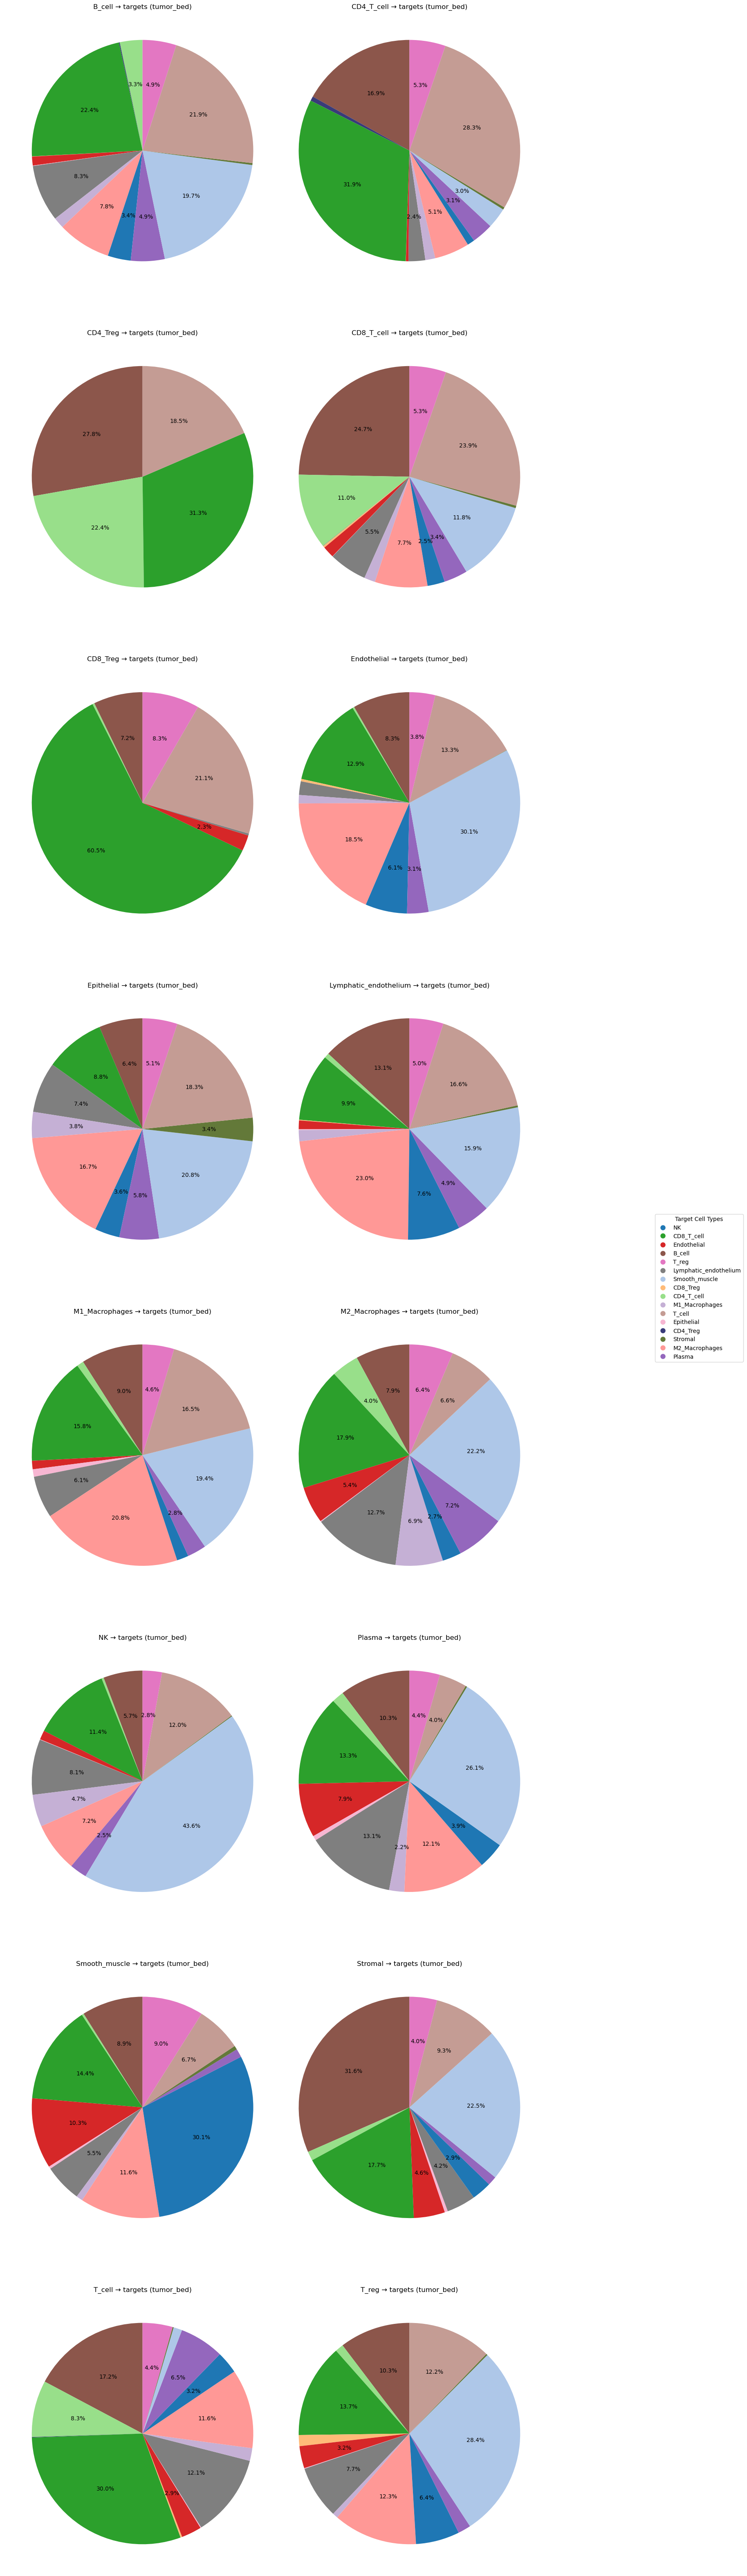


=== Condition: tumor ===


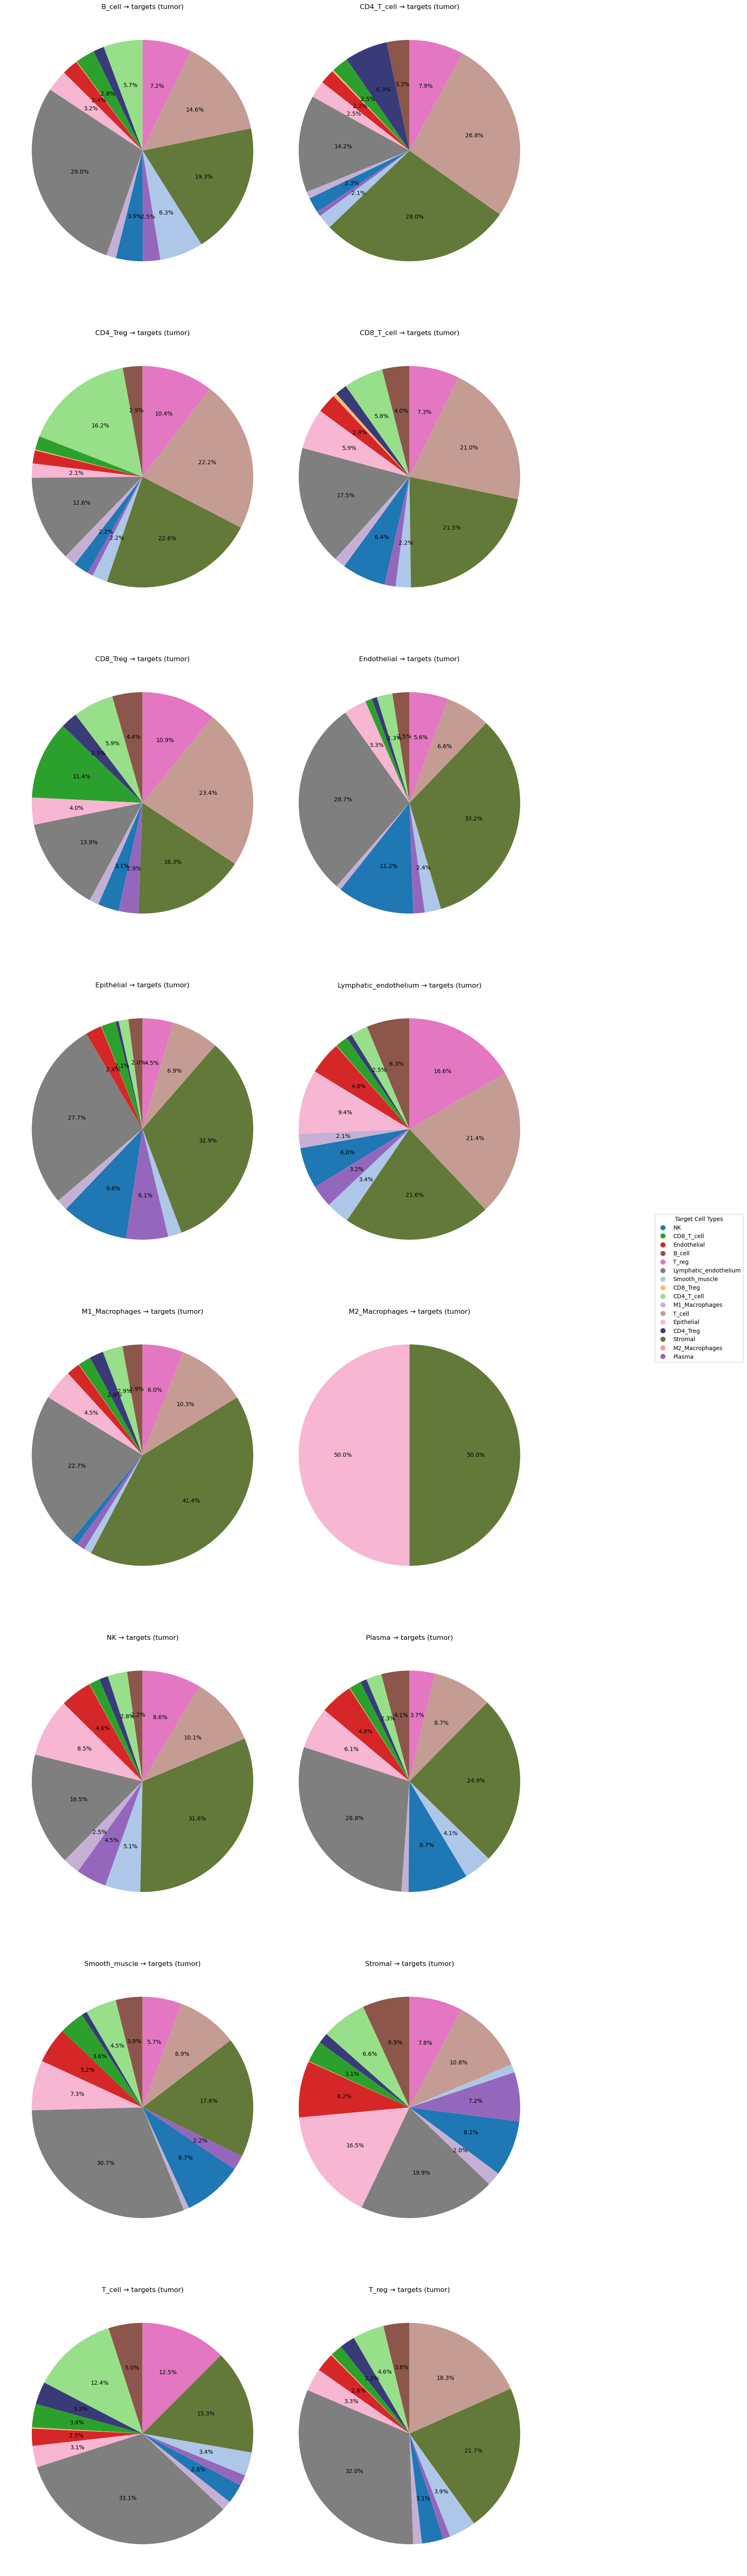


=== Condition: tumor_inner ===


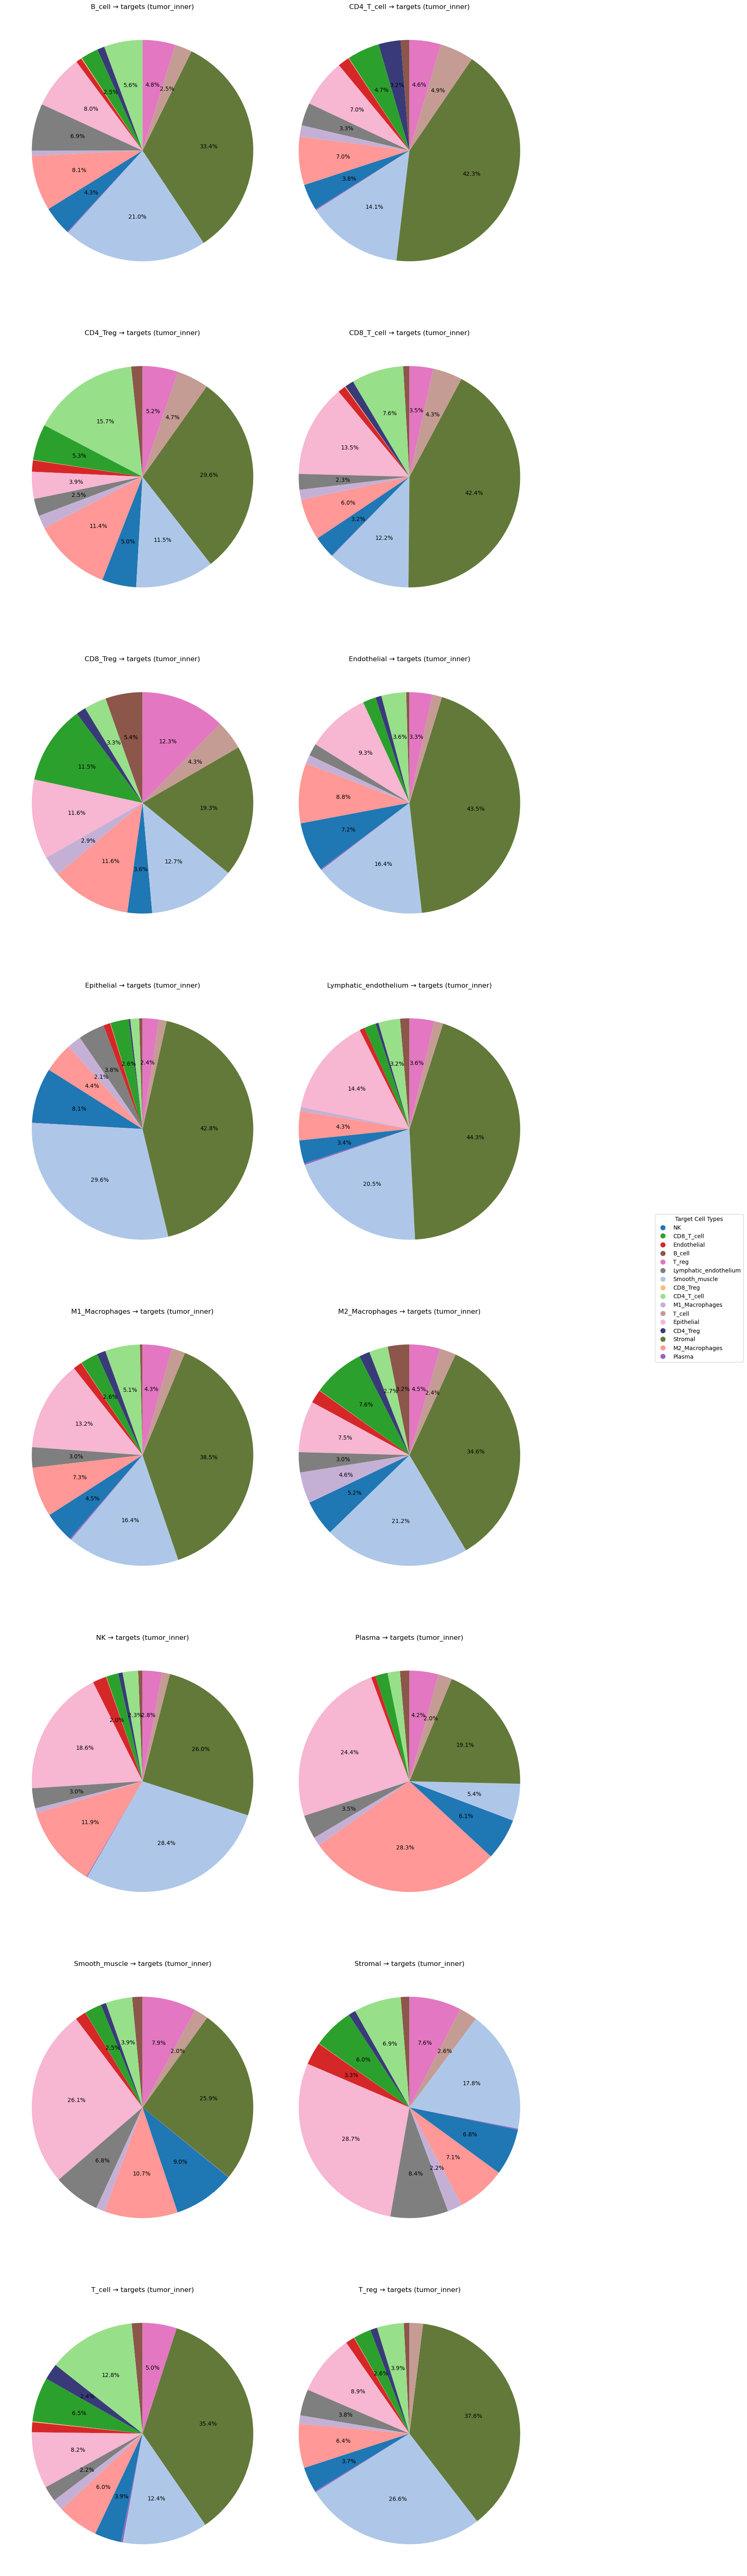

In [144]:
ncols = 2
np.random.seed(42)

for cond, pivot_df in pivot_dfs.items():
    print(f"\n=== Condition: {cond} ===")

    row_props = pivot_df
    n_rows = math.ceil(len(row_props) / ncols)
    fig, axes = plt.subplots(n_rows, ncols, figsize=(8 * ncols, 8 * n_rows))

    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

    for i, (source_cell, pie_data) in enumerate(row_props.iterrows()):
        ax = axes[i]
        pie_colors = [celltype_colors[label] for label in pie_data.index]

        wedges, texts, autotexts = ax.pie(
            pie_data,
            labels=None,  # hide labels on the pie
            autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
            startangle=90,
            colors=pie_colors
        )
        ax.set_title(f"{source_cell} → targets ({cond})", fontsize=12)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    # Add a single legend outside the entire figure
    fig.legend(
        handles=[plt.Line2D([0], [0], marker='o', color='w', label=lbl, 
                            markerfacecolor=clr, markersize=10)
                 for lbl, clr in celltype_colors.items()],
        loc='center left',
        bbox_to_anchor=(1.0, 0.5),
        title="Target Cell Types"
    )

    plt.tight_layout(rect=[0, 0, 0.85, 1])  # leave space on the right for the legend
    plt.show()


In [145]:
from itertools import combinations
from scipy.stats import ttest_ind
import pandas as pd

# List of conditions
conditions = list(neighbor_dfs.keys())

# Initialize list to collect t-test results
ttest_results = []

# Get all unique cell types and neighbor types
cell_types = pd.concat(neighbor_dfs.values())['cell_type'].unique()
neighbor_types = pd.concat(neighbor_dfs.values())['neighbor_cell_type'].unique()

# Loop over all cell types and neighbor types
for cell in cell_types:
    for neighbor in neighbor_types:
        # Loop over all pairs of conditions
        for cond1, cond2 in combinations(conditions, 2):
            df1 = neighbor_dfs[cond1]
            df2 = neighbor_dfs[cond2]

            # Subset the relevant proportions
            group1 = df1[(df1['cell_type'] == cell) & 
                         (df1['neighbor_cell_type'] == neighbor)]['proportion']
            #print(group1.isna().any())
            group2 = df2[(df2['cell_type'] == cell) & 
                         (df2['neighbor_cell_type'] == neighbor)]['proportion']
            #print(group2.isna().any())

            # Skip if either group is empty
            if len(group1) == 0 or len(group2) == 0:
                continue
            mean1 = group1.mean()
            mean2 = group2.mean()

            # Perform t-test
            t_stat, p_val = ttest_ind(group1, group2, equal_var=False)

            # Store result
            ttest_results.append({
                'cell_type': cell,
                'neighbor_cell_type': neighbor,
                'cond1': cond1,
                'cond2': cond2,
                'mean_cond1': mean1,
                'mean_cond2': mean2,
                't_stat': t_stat,
                'p_value': p_val
            })

# Convert to DataFrame
ttest_df = pd.DataFrame(ttest_results)

# Optional: adjust for multiple testing (Bonferroni, FDR, etc.)


/home/maa7095/miniconda3/envs/sc_python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1114: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/home/maa7095/miniconda3/envs/sc_python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1114: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


In [146]:
ttest_df[ttest_df['cell_type']=='T_reg']

,cell_type,neighbor_cell_type,cond1,cond2,mean_cond1,mean_cond2,t_stat,p_value
204,T_reg,CD8_T_cell,tumor_bed,tumor,0.159024,0.018299,2.380032,0.072673
205,T_reg,CD8_T_cell,tumor_bed,tumor_inner,0.159024,0.025580,2.271862,0.083792
206,T_reg,CD8_T_cell,tumor,tumor_inner,0.018299,0.025580,-0.618584,0.556466
207,T_reg,T_cell,tumor_bed,tumor,0.142110,0.193397,-0.362005,0.737195
208,T_reg,T_cell,tumor_bed,tumor_inner,0.142110,0.019695,0.908833,0.429833
209,T_reg,T_cell,tumor,tumor_inner,0.193397,0.019695,3.780461,0.016612
210,T_reg,Lymphatic_endothelium,tumor_bed,tumor,0.089944,0.336974,-1.803993,0.133522
211,T_reg,Lymphatic_endothelium,tumor_bed,tumor_inner,0.089944,0.038422,1.179836,0.311548
212,T_reg,Lymphatic_endothelium,tumor,tumor_inner,0.336974,0.038422,2.279589,0.083643
213,T_reg,B_cell,tumor_bed,tumor,0.120042,0.039916,1.189585,0.294083


In [147]:
ttest_df[ttest_df['cell_type']=='CD8_T_cell']

,cell_type,neighbor_cell_type,cond1,cond2,mean_cond1,mean_cond2,t_stat,p_value
82,CD8_T_cell,T_cell,tumor_bed,tumor,0.270962,0.241687,0.143077,0.893835
83,CD8_T_cell,T_cell,tumor_bed,tumor_inner,0.270962,0.043875,1.160127,0.328560
84,CD8_T_cell,T_cell,tumor,tumor_inner,0.241687,0.043875,3.033441,0.031353
85,CD8_T_cell,Lymphatic_endothelium,tumor_bed,tumor,0.062779,0.201958,-1.597557,0.172190
86,CD8_T_cell,Lymphatic_endothelium,tumor_bed,tumor_inner,0.062779,0.023441,1.357602,0.259313
87,CD8_T_cell,Lymphatic_endothelium,tumor,tumor_inner,0.201958,0.023441,2.158855,0.096145
88,CD8_T_cell,T_reg,tumor_bed,tumor,0.060524,0.084141,-0.866479,0.411613
89,CD8_T_cell,T_reg,tumor_bed,tumor_inner,0.060524,0.035095,1.226304,0.279488
90,CD8_T_cell,T_reg,tumor,tumor_inner,0.084141,0.035095,2.545596,0.054967
91,CD8_T_cell,B_cell,tumor_bed,tumor,0.280173,0.045888,2.746723,0.048930
